## Main Objective
The main objective is to predict the likelihood of heart disease!

### Dataset
1. **id**: unique identifier.
2. **Age**: Age of the patient (in years).
3. **Sex**: Gender of the patient (1 = Male, 0 = Female)
4. **Chest pain type**:  1 = Typical angina, 2 = Atypical angina,  3 = Non-anginal pain, 4 = Asymptomatic!
5. **BP**: Resting blood pressure (mm Hg).
6. **Cholesterol**: Serum cholesterol level (mg/dL).
7. **FBS over 120**: Fasting blood sugar > 120 mg/dL (1 = True, 0 = False).
8. **EKG results**: 0 = Normal, 1 = ST-T wave abnormality, 2 = Left ventricular hypertrophy.
9. **Max HR**: Maximum heart rate achieved.
10. **Exercise angina**: Exercise-induced angina (1 = Yes, 0 = No).
11. **ST depression**: ST depression induced by exercise relative to rest. 
12. **Slope of ST**: Slope of the peak exercise ST segment. 
13. **Number of vessels fluro**: Number of major vessels (0–3) colored by fluoroscopy.
14. **Thallium**: Thallium stress test result (categorical medical indicator). 
15. **Heart Disease**:  Presence = Heart disease detected, Absence = No heart disease.

### Note
> The dataset is synthetic / augmented / ML generated.
1. We are not validating real patients.
2. We are validating the data‑generation process.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Dataset/train.csv")

In [3]:
df.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [5]:
df.shape

(630000, 15)

## Exploratory Data Analysis
### Are there duplicated rows or duplicated IDs?

In [6]:
print(f"Dataset has {df.shape[0]} rows")
print(f"Number of unique IDs {df['id'].nunique()}")

Dataset has 630000 rows
Number of unique IDs 630000


### Are there constant or near‑constant features?

In [7]:
df.nunique()

id                         630000
Age                            42
Sex                             2
Chest pain type                 4
BP                             66
Cholesterol                   150
FBS over 120                    2
EKG results                     3
Max HR                         93
Exercise angina                 2
ST depression                  66
Slope of ST                     3
Number of vessels fluro         4
Thallium                        3
Heart Disease                   2
dtype: int64

In [8]:
threshold = 0.95
near_constant = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).max()
    if top_freq > threshold:
        near_constant.append((col, top_freq))

near_constant

[]

> There is no feature with constant or near-constant values!

### Are there features with extremely low variance?

In [9]:
numerical_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
categorical_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Heart Disease', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

In [10]:
df[numerical_features].var()

Age                68.166504
BP                224.274645
Cholesterol      1134.448907
Max HR            365.303961
ST depression       0.899599
dtype: float64

In [11]:
for col in categorical_features:
    top_freq = df[col].value_counts(normalize=True).max()
    print(f"{col}: {top_freq:.3f}")

Sex: 0.715
Chest pain type: 0.523
FBS over 120: 0.920
EKG results: 0.508
Exercise angina: 0.726
Heart Disease: 0.552
Slope of ST: 0.569
Number of vessels fluro: 0.708
Thallium: 0.591


> High variance (BP, Cholesterol, Max HR) → these features vary a lot and can help models separate patients.  
> Low variance (Slope of ST, Number of vessels fluro) → these features might be dominated by one or two values.  
(Low variance ≠ useless. Even rare features can be highly predictive if they correlate strongly with the target.)

### Do continuous features have reasonable distributions (no weird spikes, multimodal artifacts, or unnatural plateaus)?

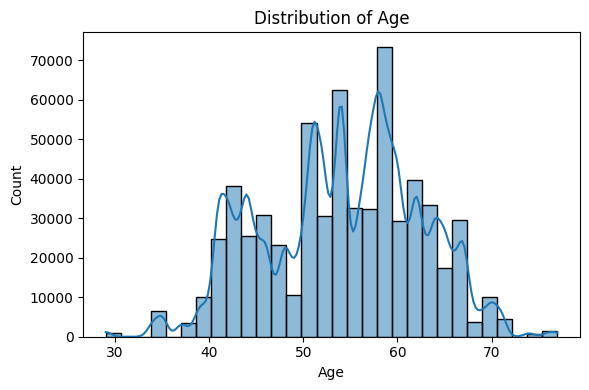

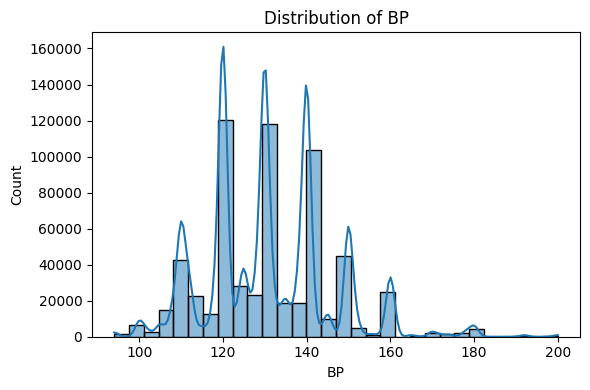

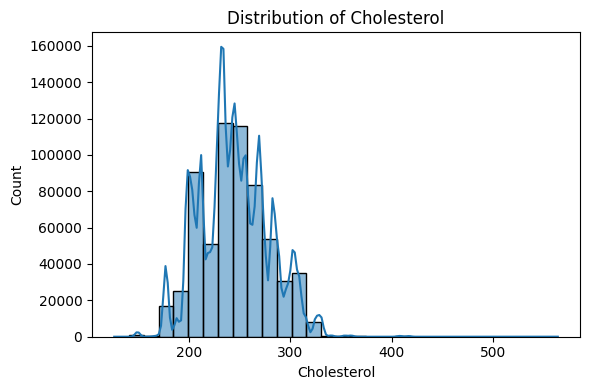

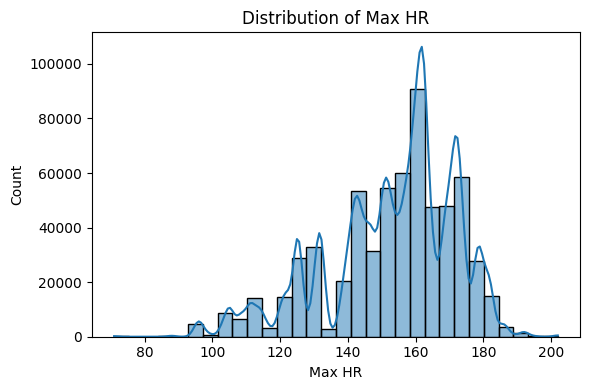

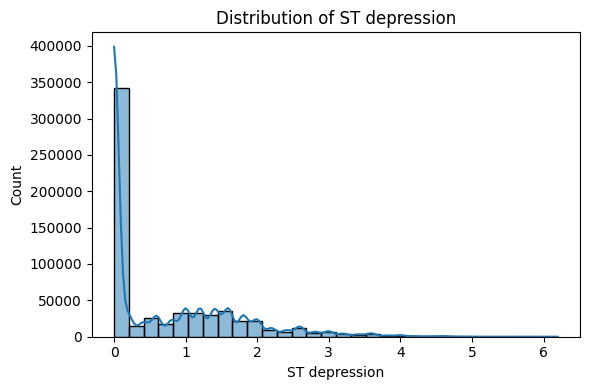

In [12]:
for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()    

> Age and BP exhibit multi-modal patterns, Cholesterol is approximately normal, Max HR is left-skewed but smooth, and ST depression behaves more like an ordinal variable with a dominant zero category.  
No feature shows suspicious spikes, plateaus, or generator artifacts that would indicate data quality issues.

### Do categorical features have balanced categories, or are some categories extremely rare?

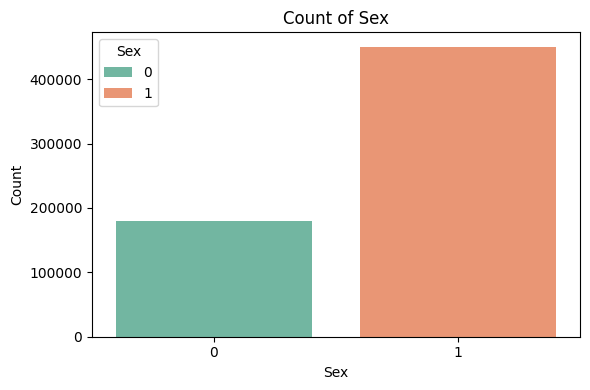

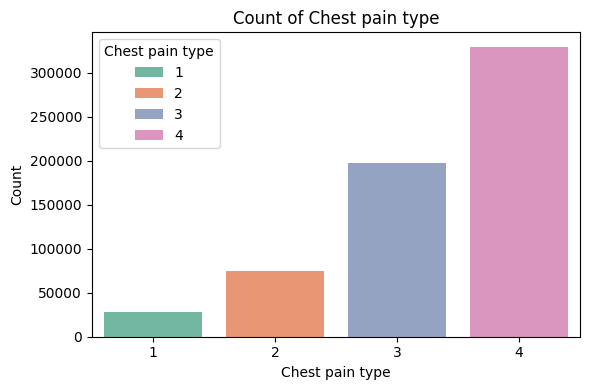

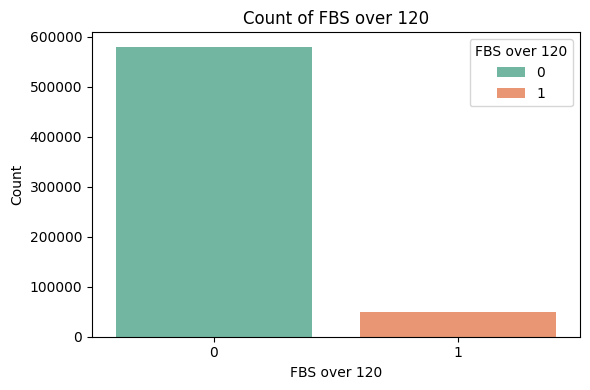

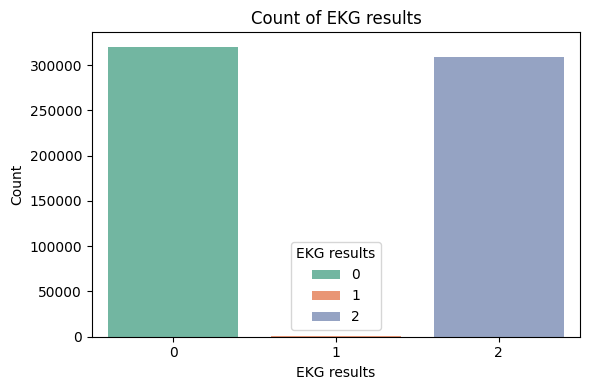

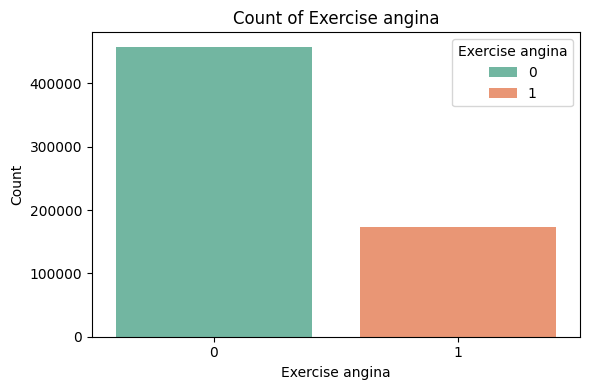

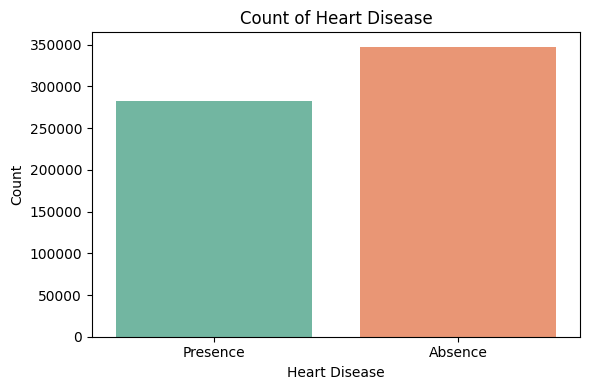

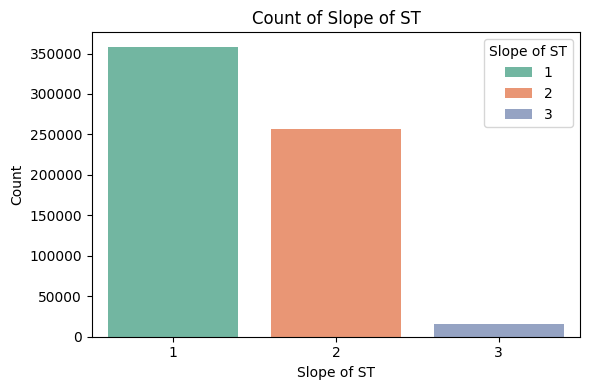

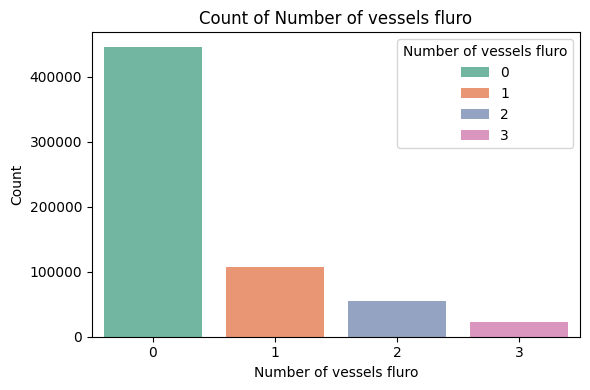

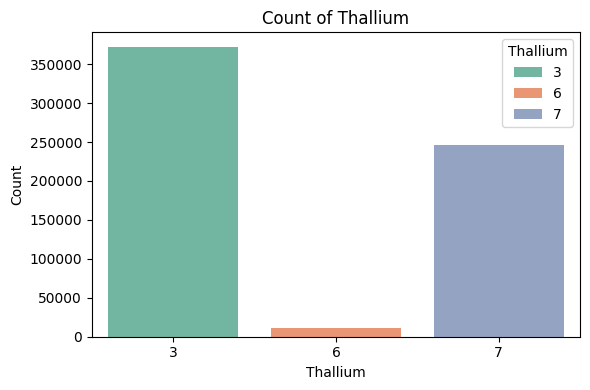

In [13]:
for cat in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=cat, data=df, hue=cat, palette="Set2")
    plt.title(f"Count of {cat}")
    plt.xlabel(cat)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

> FBS, Exercise Angina, and Heart Disease are well distributed. EKG results, Slope of ST, and Thallium each contain one very small category (<2%), which could introduce noise or instability in some models.  
No categorical feature shows pathological imbalance, but some categories are clearly underrepresented.  
Target feature is very balanced. 

### Which features show strong separation between classes?
(A feature separates classes if patients with heart disease tend to have different values than patients without heart disease.)

Heart Disease  Absence  Presence
Sex                             
0               147590     32127
1               199956    250327


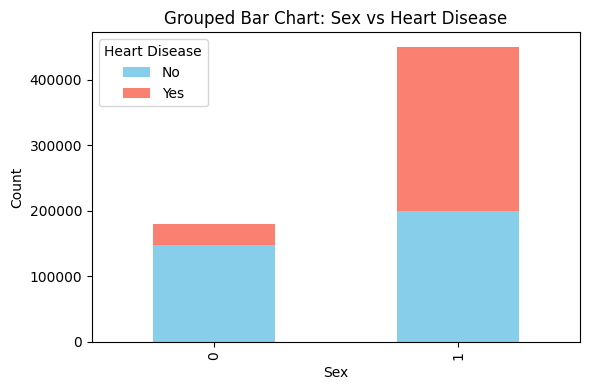

Heart Disease    Absence  Presence
Chest pain type                   
1                  25511      3091
2                  62787     12154
3                 159664     37614
4                  99584    229595


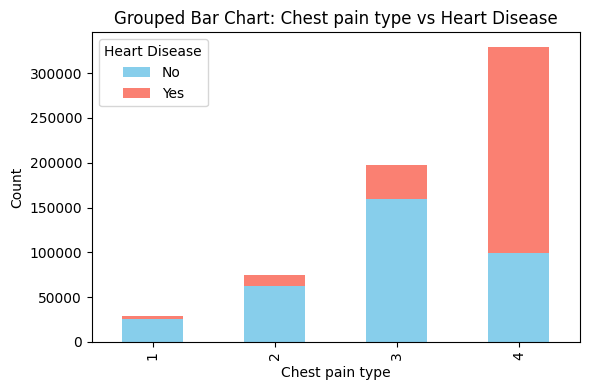

Heart Disease  Absence  Presence
FBS over 120                    
0               322600    257008
1                24946     25446


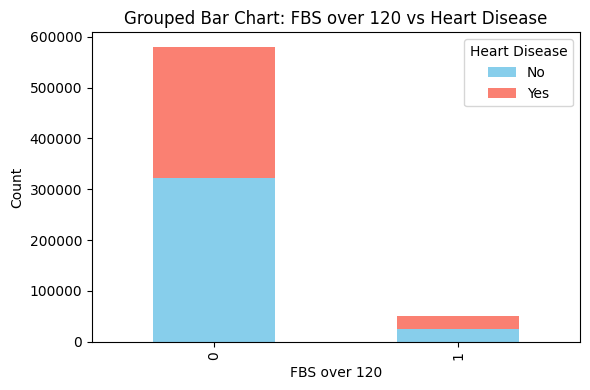

Heart Disease  Absence  Presence
EKG results                     
0               210797    109319
1                  846       476
2               135903    172659


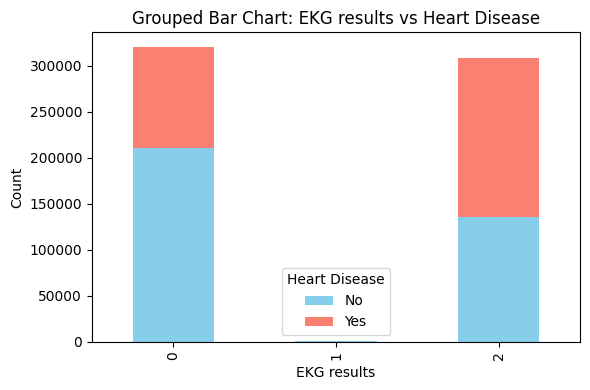

Heart Disease    Absence  Presence
Exercise angina                   
0                 314141    143412
1                  33405    139042


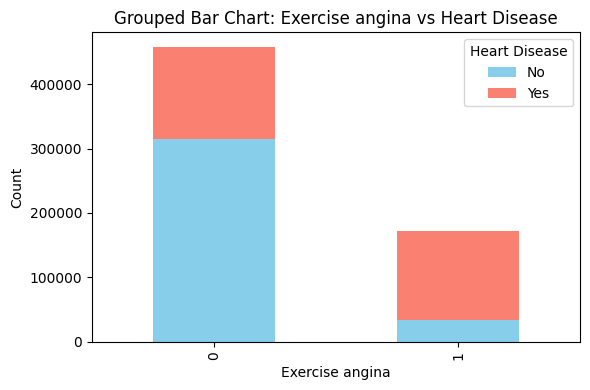

Heart Disease   Absence  Presence
Heart Disease                    
Absence        347546.0       NaN
Presence            NaN  282454.0


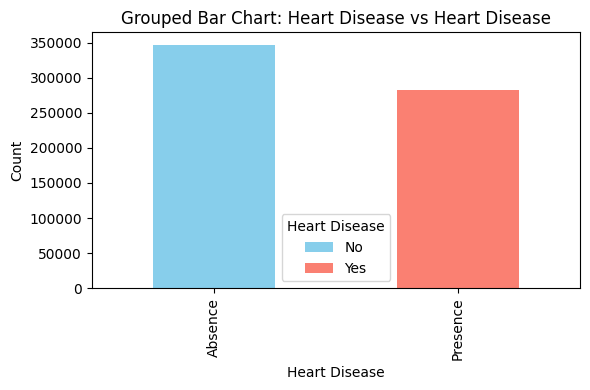

Heart Disease  Absence  Presence
Slope of ST                     
1               264328     93965
2                78897    177318
3                 4321     11171


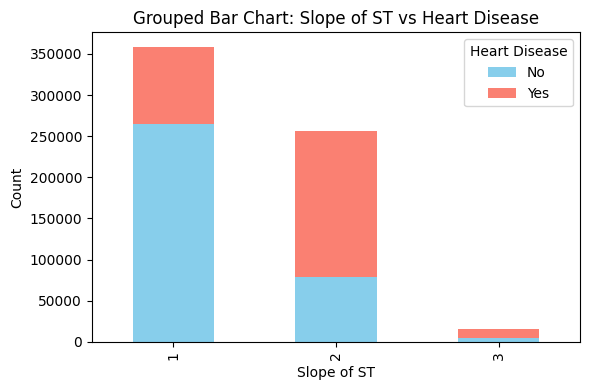

Heart Disease            Absence  Presence
Number of vessels fluro                   
0                         310707    135155
1                          28954     78024
2                           5589     48714
3                           2296     20561


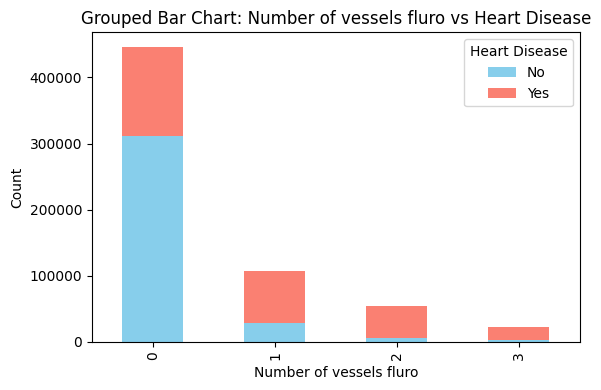

Heart Disease  Absence  Presence
Thallium                        
3               298555     73731
6                 3439      7527
7                45552    201196


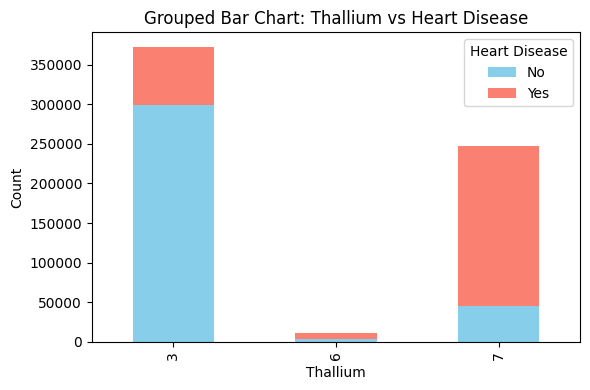

In [14]:
for cat in categorical_features:
    counts = df.groupby([cat, 'Heart Disease']).size().unstack()
    print(counts)
    counts.plot(kind='bar', stacked=True, figsize=(6,4), color=['skyblue', 'salmon'])
    plt.title(f"Grouped Bar Chart: {cat} vs Heart Disease")    
    plt.ylabel("Count")
    plt.xlabel(cat)
    plt.legend(title="Heart Disease", labels=["No", "Yes"])
    plt.tight_layout()
    plt.show()

**Sex**: 
> Females: mostly Absence. Males: mostly Presence. This is strong separation. Sex is clearly predictive.

**Chest pain type**: 
> Type 4 (asymptomatic) is heavily associated with Presence. Type 1 is heavily associated with Absence.

**FBS over 120**:
> Both categories have similar proportions across classes.

**EKG results**:
> Category 2 is more common in Presence. Category 0 is more common in Absence.

**Exercise angina**:
> Angina during exercise is strongly associated with disease.

**Slope of ST**:
> Slope 2 and 3 lean toward Presence. Slope 1 leans toward Absence.

**Number of vessels fluro**:
> More vessels colored → much higher chance of disease.

**Thallium**:
> Thallium = 7 is strongly associated with disease. Thallium = 3 is strongly associated with no disease.

### Are there nonlinear relationships?

In [18]:
# Converting target-feature to binary
df['HeartDisease_binary'] = (df['Heart Disease'] == 'Presence').astype(int)

<Axes: xlabel='Age'>

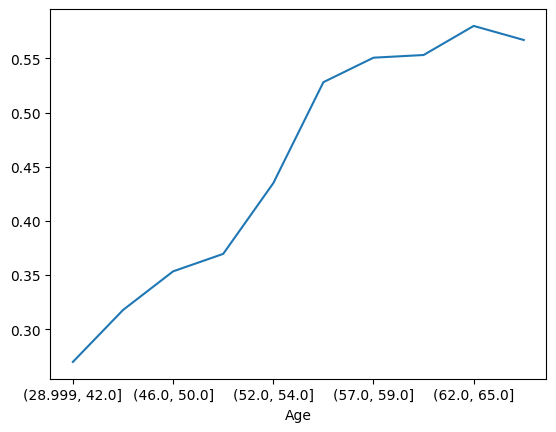

In [27]:
df.groupby(pd.qcut(df['Age'], 10), observed=True)['HeartDisease_binary'].mean().plot()

<Axes: xlabel='Cholesterol'>

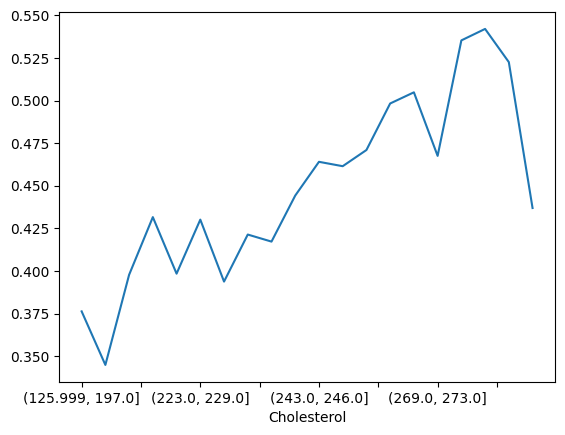

In [31]:
df.groupby(pd.qcut(df['Cholesterol'], 20), observed=True)['HeartDisease_binary'].mean().plot()

<Axes: xlabel='BP'>

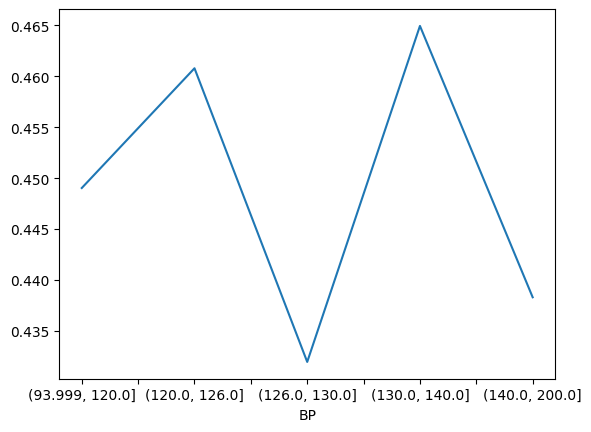

In [36]:
df.groupby(pd.qcut(df['BP'], 5), observed=True)['HeartDisease_binary'].mean().plot()

<Axes: xlabel='Max HR'>

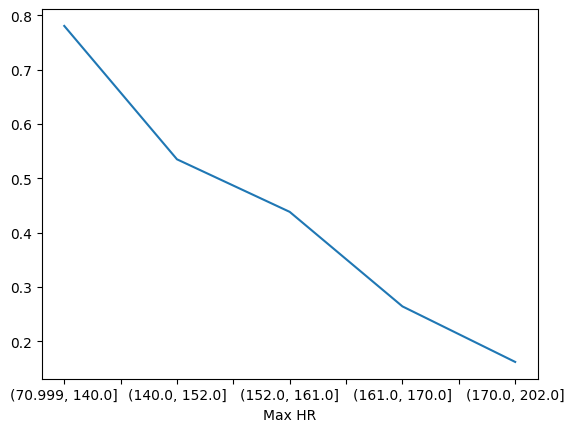

In [41]:
df.groupby(pd.qcut(df['Max HR'], 5), observed=True)['HeartDisease_binary'].mean().plot()

> How disease probability changes across different feature's bins show that there are non-linear relationships between continuous features and the target feature.    
Categorical features are non‑linear by nature because: 1. Each category has its own risk level. 2. The relationship is step‑wise, not continuous.

### Are any features highly correlated?

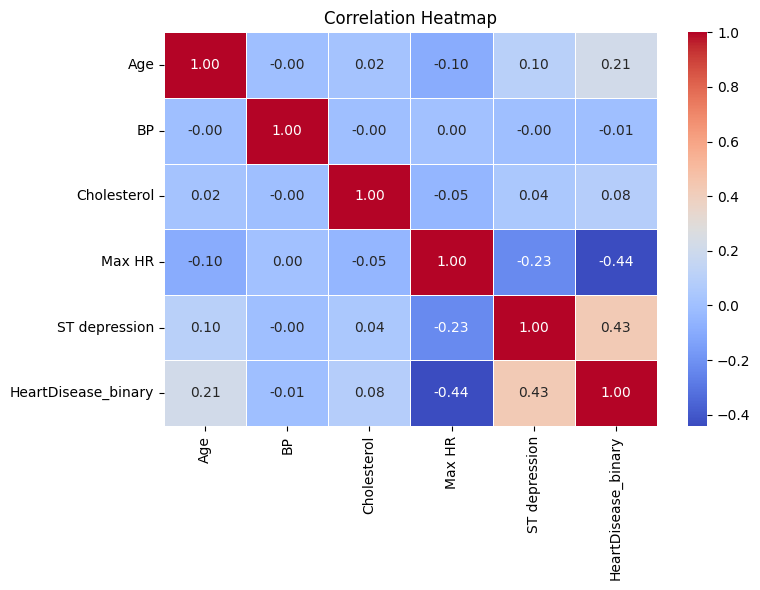

In [48]:
corr = df[numerical_features + ['HeartDisease_binary']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

> ST depression vs target: +0.43. (Higher ST depression → higher probability of heart disease) (Linear Relationship)  
> Max HR vs target: –0.44. (Higher Max HR → lower probability of heart disease) (Linear Relationship)  
> Age vs target: +0.21 (Older age → higher probability of heart disease) 
> Cholesterol barely correlates with disease in this dataset. 
> BP does not separate classes linearly. 

### Are there features that perfectly or near‑perfectly predict the target?

> No feature is perfectly predictive.  
But some are very strong, like:  
> 1. Chest pain type = 4.
> 2. Thallium = 7
> 3. Number of vessels fluro = 2 or 3
> 4. Exercise angina = 1

In [19]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,HeartDisease_binary
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence,1
